# Step 1: Data Preparation and Annotation Verification

This section randomly selects a few images from the training set, loads the YOLO-format annotations, uses the dedicated conversion function (`convert_yolo_to_absolute`) to obtain absolute bounding box coordinates, prints the coordinate values, and visualizes the annotations on the images.



Total annotations for gunnerus_vertikal_2_ny_249.jpg: 2 (Before Conversion: 2, After Conversion: 2)
Image: gunnerus_vertikal_2_ny_249.jpg
Class: 0
Normalized: (0.71201, 0.03976, 0.066176, 0.07952)
Absolute: (869.0201600000001, 0.0, 953.72544, 76.33919999999999)
------
Image: gunnerus_vertikal_2_ny_249.jpg
Class: 0
Normalized: (0.885212, 0.388344, 0.14134, 0.29085)
Absolute: (1042.61376, 233.20224000000002, 1223.5289599999999, 512.41824)
------


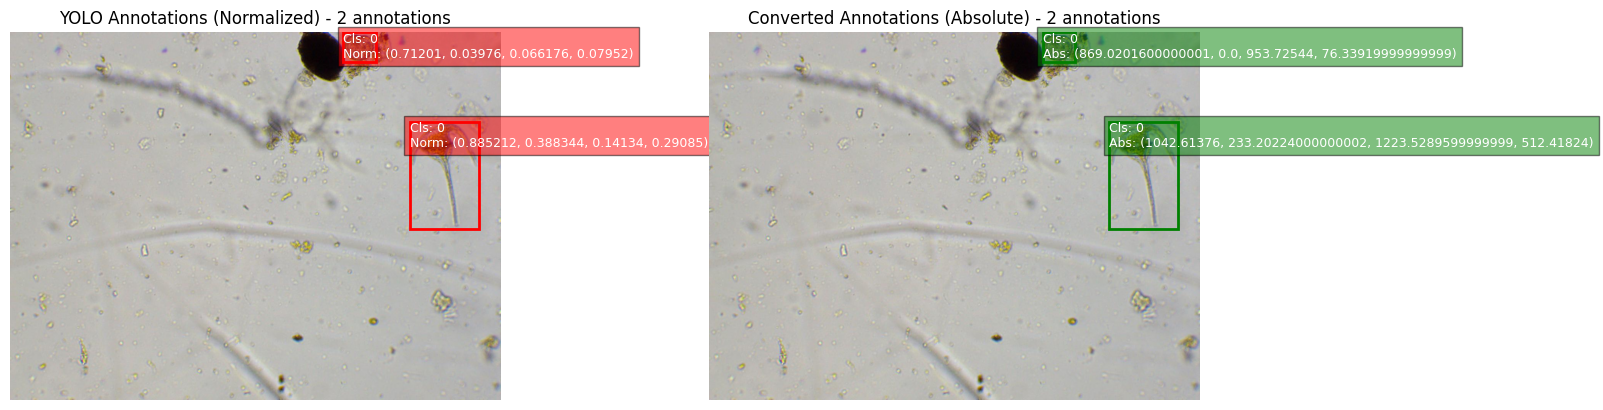

Total annotations for 7295.jpg: 1 (Before Conversion: 1, After Conversion: 1)
Image: 7295.jpg
Class: 0
Normalized: (0.432353, 0.697266, 0.101471, 0.490234)
Absolute: (518.9998, 463.000576, 657.00036, 965.0001920000001)
------


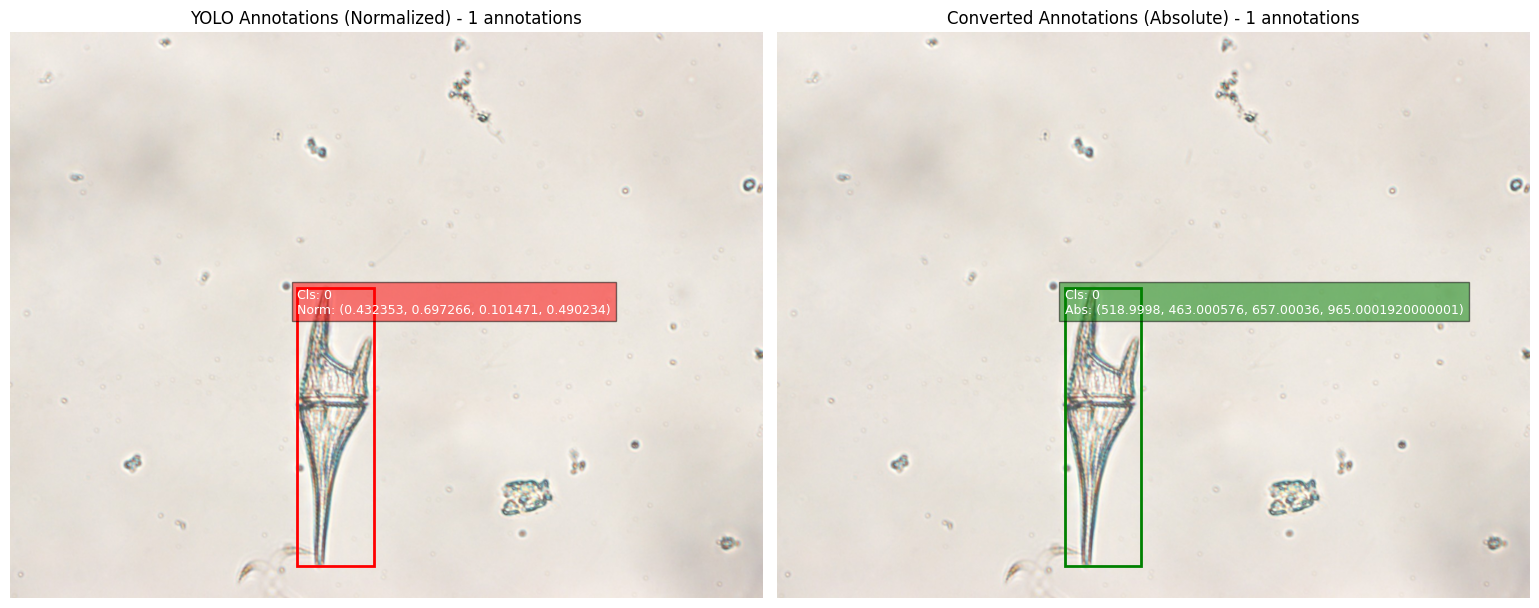

Total annotations for 3745.jpg: 2 (Before Conversion: 2, After Conversion: 2)
Image: 3745.jpg
Class: 0
Normalized: (0.451838, 0.608887, 0.105147, 0.452148)
Absolute: (542.99972, 392.00051199999996, 685.99964, 855.000064)
------
Image: 3745.jpg
Class: 0
Normalized: (0.579044, 0.232422, 0.072794, 0.287109)
Absolute: (737.99992, 91.00031999999999, 836.9997599999999, 384.999936)
------


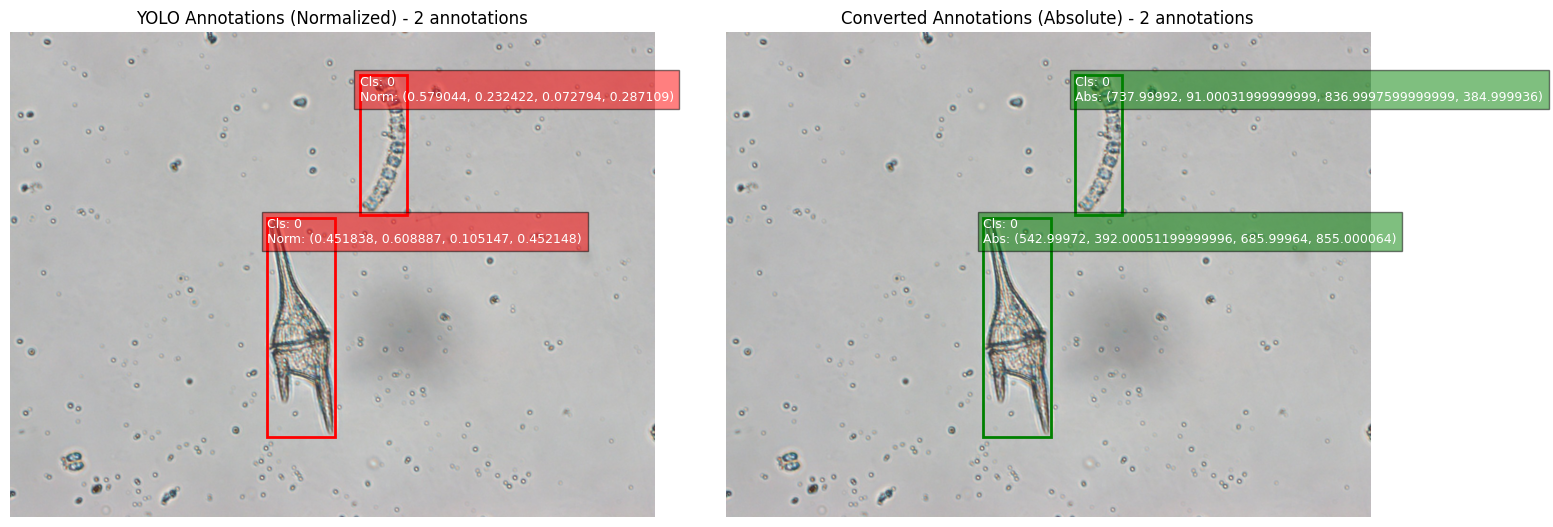

Total annotations for 8038.jpg: 1 (Before Conversion: 1, After Conversion: 1)
Image: 8038.jpg
Class: 0
Normalized: (0.615809, 0.435059, 0.768382, 0.81543)
Absolute: (315.00048000000004, 28.00025599999998, 1360.0, 863.0005759999999)
------


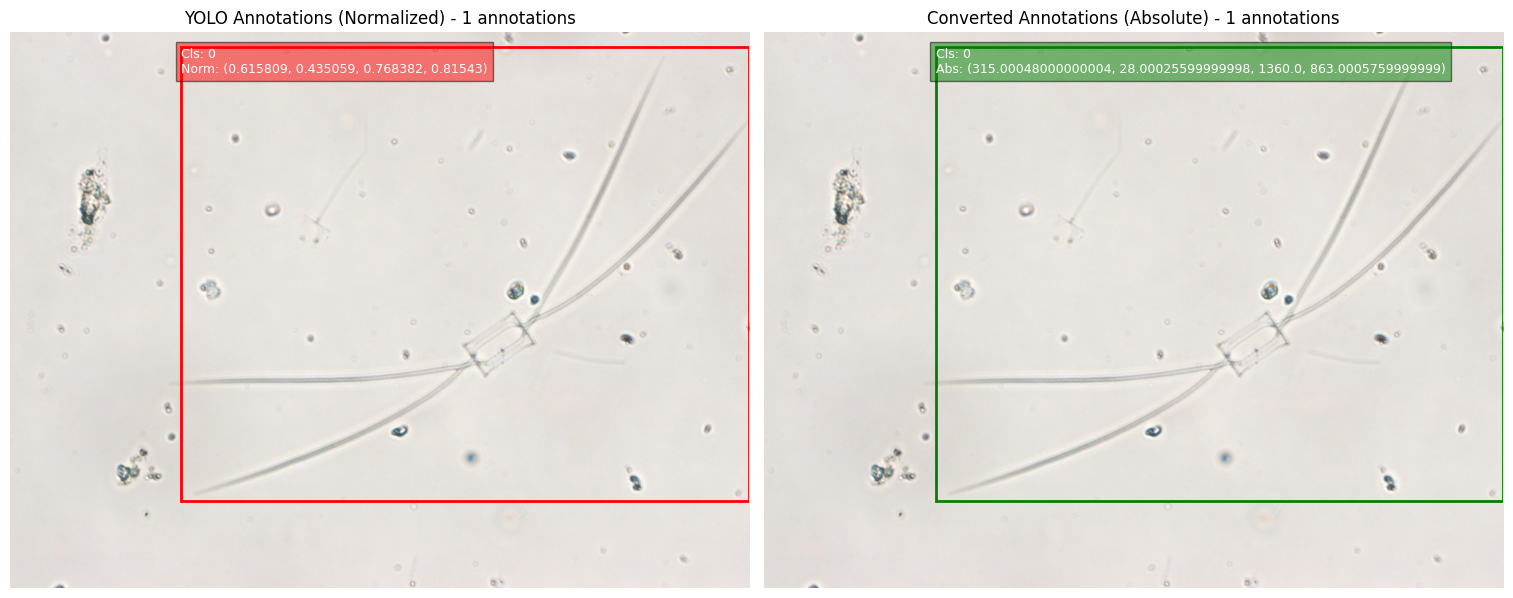

Total annotations for gunnerus_vertikal_2_ny_211.jpg: 4 (Before Conversion: 4, After Conversion: 4)
Image: gunnerus_vertikal_2_ny_211.jpg
Class: 0
Normalized: (0.921977, 0.744009, 0.066176, 0.267974)
Absolute: (1137.77792, 585.62112, 1222.4832000000001, 842.87616)
------
Image: gunnerus_vertikal_2_ny_211.jpg
Class: 0
Normalized: (0.946078, 0.267974, 0.107843, 0.217865)
Absolute: (1141.96032, 152.67984, 1279.99936, 361.83024)
------
Image: gunnerus_vertikal_2_ny_211.jpg
Class: 0
Normalized: (0.115196, 0.203159, 0.140523, 0.271242)
Absolute: (57.51616000000001, 64.83648000000002, 237.3856, 325.2288)
------
Image: gunnerus_vertikal_2_ny_211.jpg
Class: 0
Normalized: (0.640931, 0.934641, 0.120098, 0.130718)
Absolute: (743.5289600000001, 834.5107200000001, 897.2544, 960.0000000000001)
------


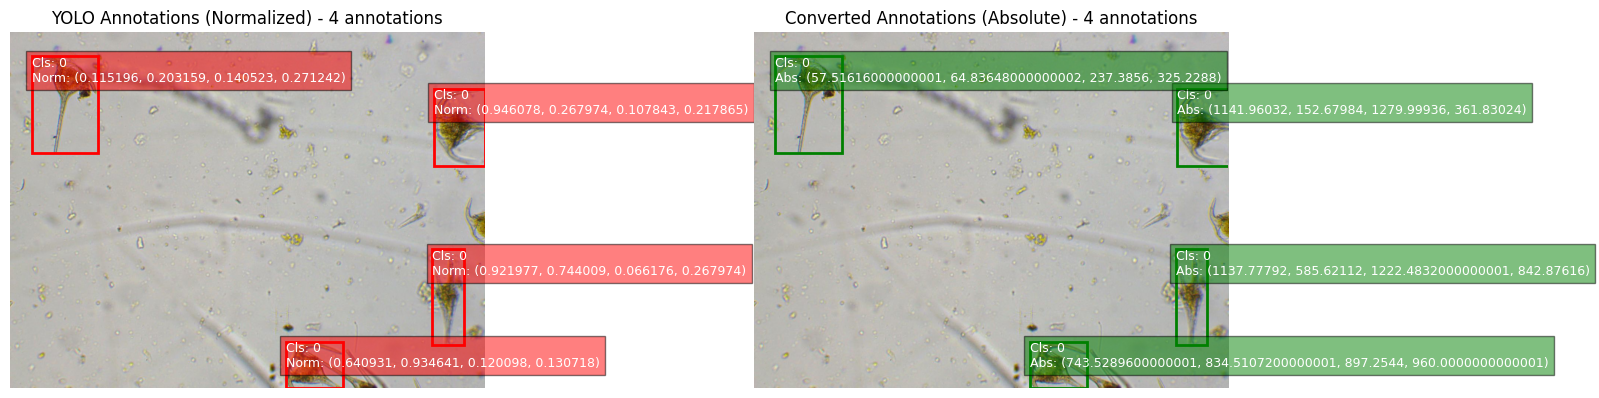

In [17]:
# %% [code]
import os
import random
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- Configuration for Verification ---
train_images_dir = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/train/images"
train_labels_dir = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/train/labels"
num_samples = 5  # Number of random images to verify

# --- Conversion Function ---
def convert_yolo_to_absolute(x_center_norm, y_center_norm, w_norm, h_norm, img_width, img_height):
    """
    Convert normalized YOLO annotation to absolute coordinates.
    
    Parameters:
      - x_center_norm, y_center_norm, w_norm, h_norm: Normalized annotation values.
      - img_width, img_height: Dimensions of the image.
    
    Returns:
      - (xmin, ymin, xmax, ymax): Absolute bounding box coordinates.
    """
    x_center = x_center_norm * img_width
    y_center = y_center_norm * img_height
    w = w_norm * img_width
    h = h_norm * img_height
    xmin = x_center - w / 2
    ymin = y_center - h / 2
    xmax = x_center + w / 2
    ymax = y_center + h / 2
    return (xmin, ymin, xmax, ymax)

# --- Function to Load and Parse Annotations ---
def load_annotations(label_path):
    """
    Loads YOLO annotations from a label file.
    
    Returns:
      - A list of dictionaries, each containing:
          'class_id': integer class id,
          'normalized': (x_center_norm, y_center_norm, w_norm, h_norm)
    """
    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue  # Skip invalid lines.
                class_id = int(parts[0])
                values = tuple(map(float, parts[1:]))  # (x_center_norm, y_center_norm, w_norm, h_norm)
                annotations.append({
                    'class_id': class_id,
                    'normalized': values
                })
    return annotations

# --- Dual Visualization Function ---
def visualize_dual_annotations(image_path, label_path):
    """
    Displays a horizontal collage for a given image:
      - Left: Image with bounding boxes and YOLO normalized annotation text.
      - Right: Same image with bounding boxes and converted absolute annotation text.
    Also shows the number of annotations (before and after conversion) in the subplot titles and prints a summary.
    """
    # Load image.
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width, _ = img.shape
    
    # Load annotations.
    annots = load_annotations(label_path)
    num_annots = len(annots)
    
    # Print summary of annotation counts.
    print(f"Total annotations for {os.path.basename(image_path)}: {num_annots} "
          f"(Before Conversion: {num_annots}, After Conversion: {num_annots})")
    
    # Prepare figure with two horizontal subplots.
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 8))
    ax_left.imshow(img_rgb)
    ax_right.imshow(img_rgb)
    
    # Set titles with annotation counts.
    ax_left.set_title(f"YOLO Annotations (Normalized) - {num_annots} annotations")
    ax_right.set_title(f"Converted Annotations (Absolute) - {num_annots} annotations")
    
    # Loop through each annotation and overlay bounding boxes.
    for annot in annots:
        class_id = annot['class_id']
        x_center_norm, y_center_norm, w_norm, h_norm = annot['normalized']
        
        # Convert using the conversion function.
        abs_bbox = convert_yolo_to_absolute(x_center_norm, y_center_norm, w_norm, h_norm, img_width, img_height)
        xmin, ymin, xmax, ymax = abs_bbox
        
        # Left subplot: Show YOLO normalized info (display box at same location).
        rect_left = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                      linewidth=2, edgecolor='r', facecolor='none')
        ax_left.add_patch(rect_left)
        ax_left.text(xmin, ymin, f"Cls: {class_id}\nNorm: {annot['normalized']}", 
                     fontsize=9, color='white', verticalalignment='top', bbox=dict(facecolor='red', alpha=0.5))
        
        # Right subplot: Show converted absolute info.
        rect_right = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                       linewidth=2, edgecolor='g', facecolor='none')
        ax_right.add_patch(rect_right)
        ax_right.text(xmin, ymin, f"Cls: {class_id}\nAbs: {abs_bbox}", 
                      fontsize=9, color='white', verticalalignment='top', bbox=dict(facecolor='green', alpha=0.5))
        
        # Also print individual annotation details.
        print(f"Image: {os.path.basename(image_path)}")
        print(f"Class: {class_id}")
        print(f"Normalized: {annot['normalized']}")
        print(f"Absolute: {abs_bbox}")
        print("------")
    
    ax_left.axis('off')
    ax_right.axis('off')
    plt.tight_layout()
    plt.show()

# --- Main Execution for Verification ---
all_images = [f for f in os.listdir(train_images_dir) if f.lower().endswith(('.jpg', '.png'))]
sample_images = random.sample(all_images, min(num_samples, len(all_images)))
for img_filename in sample_images:
    img_path = os.path.join(train_images_dir, img_filename)
    label_filename = os.path.splitext(img_filename)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_filename)
    visualize_dual_annotations(img_path, label_path)


In [18]:
# %% [code]
# --- Overall Annotations Summary ---
# This cell summarizes the total number of annotations in the dataset and verifies that the conversion
# process does not alter the count of annotations.

# Directories (adjust if necessary)
train_images_dir = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/train/images"
train_labels_dir = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/train/labels"

# Initialize counters.
total_yolo_annotations = 0
total_converted_annotations = 0

# Get all image filenames.
all_images = [f for f in os.listdir(train_images_dir) if f.lower().endswith(('.jpg', '.png'))]

# Iterate over each image file.
for img_filename in all_images:
    # Build corresponding label file path.
    label_filename = os.path.splitext(img_filename)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_filename)
    
    # Load YOLO annotations.
    annots = load_annotations(label_path)  # Uses the load_annotations function defined earlier.
    num_annots = len(annots)
    
    # Count YOLO annotations.
    total_yolo_annotations += num_annots
    
    # For each annotation, a conversion is performed, but the count remains the same.
    # We simulate the conversion step here.
    for annot in annots:
        # Unpack normalized values.
        x_center_norm, y_center_norm, w_norm, h_norm = annot['normalized']
        # We would convert the annotation here; the count remains unchanged.
        _ = convert_yolo_to_absolute(x_center_norm, y_center_norm, w_norm, h_norm, 1, 1)  # Dummy conversion.
    total_converted_annotations += num_annots

# Print overall summary.
print("Overall Annotations Summary:")
print(f"Total YOLO annotations: {total_yolo_annotations}")
print(f"Total Converted annotations (Faster R-CNN format): {total_converted_annotations}")

# Verify that counts match.
if total_yolo_annotations == total_converted_annotations:
    print("Verification Passed: Annotation counts are identical after conversion.")
else:
    print("Verification Error: Annotation counts differ after conversion.")


Overall Annotations Summary:
Total YOLO annotations: 1183
Total Converted annotations (Faster R-CNN format): 1183
Verification Passed: Annotation counts are identical after conversion.


# Step 2: Training Process and Logging

This section creates training and validation datasets using the YOLODataset (which reuses our conversion function), sets up data loaders with updated paths, builds a Faster R-CNN model with default hyperparameters, and runs a training loop with logging of training and validation losses.



In [20]:
# %% [code]
import os
import cv2
import torch
import numpy as np
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms.functional as TF
import time

# --- Conversion Function from Step 1 used below---
# convert_yolo_to_absolute
    

# --- YOLODataset Definition ---
# This dataset class loads an image and its corresponding YOLO label file.
# It uses the conversion function above to convert normalized annotations to absolute coordinates.
class YOLODataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        """
        Args:
            images_dir (str): Directory containing images.
            labels_dir (str): Directory containing YOLO-format label files.
            transforms (callable, optional): Optional transforms to be applied on an image.
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms
        # List of image files with .jpg or .png extension.
        self.images = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # --- Load the Image ---
        img_filename = self.images[idx]
        img_path = os.path.join(self.images_dir, img_filename)
        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Image not found: {img_path}")
        # Convert BGR (OpenCV default) to RGB.
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width, _ = img.shape
        
        # --- Load and Process the Label File ---
        label_filename = os.path.splitext(img_filename)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_filename)
        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as file:
                for line in file:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue  # Skip lines not following YOLO format.
                    class_id = int(parts[0])
                    x_center_norm, y_center_norm, w_norm, h_norm = map(float, parts[1:])
                    # Convert normalized coordinates to absolute coordinates.
                    bbox = convert_yolo_to_absolute(x_center_norm, y_center_norm, w_norm, h_norm, width, height)
                    boxes.append(bbox)
                    labels.append(class_id)
        
        # Convert lists to tensors.
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # --- Create the Target Dictionary ---
        target = {
            "boxes": boxes,          # Absolute bounding boxes.
            "labels": labels,        # Class labels.
            "image_id": torch.tensor([idx])
        }
        # Compute area of each bounding box if available.
        if boxes.numel() > 0:
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        else:
            area = torch.tensor([])
        target["area"] = area
        # Set iscrowd flag (assuming no crowd instances).
        target["iscrowd"] = torch.zeros((boxes.shape[0],), dtype=torch.int64)
        
        # --- Apply Transformations ---
        if self.transforms:
            img = self.transforms(img)
        else:
            # Convert image to tensor (normalizing to [0, 1]).
            img = TF.to_tensor(img)
        
        return img, target

# Example usage:
# dataset = YOLODataset("path/to/images", "path/to/labels")
# image, target = dataset[0]


In [ ]:
# --- Definition: collate_fn ---
def collate_fn(batch):
    return tuple(zip(*batch))

# --- Configuration for Training ---
train_images_dir = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/train/images"
train_labels_dir = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/train/labels"
val_images_dir   = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/val/images"
val_labels_dir   = "../AFTI_PMID_SINGLE_CLASS_TESTING_backup_20250215_134318/val/labels"

train_dataset = YOLODataset(train_images_dir, train_labels_dir)
val_dataset   = YOLODataset(val_images_dir, val_labels_dir)

from torch.utils.data import Subset
train_subset = Subset(train_dataset, list(range(min(50, len(train_dataset)))))  # Up to 50 images.
val_subset   = Subset(val_dataset, list(range(min(20, len(val_dataset)))))      # Up to 20 images.

batch_size = 2
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# --- Model Setup ---
def get_model(num_classes):
    """
    Loads a pre-trained Faster R-CNN model with a ResNet-50-FPN backbone,
    and adapts its classification head for the specified number of classes.
    """
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

num_classes = 2
model = get_model(num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# --- Optimizer and Scheduler Setup ---
params = [p for p in model.parameters() if p.requires_grad]
learning_rate = 0.005
optimizer = optim.SGD(params, lr=learning_rate, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# --- Training Loop with Logging and Model Saving ---
num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    start_time = time.time()
    
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        epoch_loss += losses.item()
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
    
    lr_scheduler.step()
    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {epoch_loss:.4f} - Time: {epoch_time:.2f}s")
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in target.items()} for target in targets]
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Validation Loss: {val_loss:.4f}")
    
    # Save model weights if current epoch is best so far.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"--> New best model found at epoch {best_epoch} with Validation Loss: {best_val_loss:.4f} (Weights saved)")

print(f"Training complete. Best model was found at epoch {best_epoch} with a validation loss of {best_val_loss:.4f}")